# Практика: прогноз простыми словами

Это **закрепляющее задание** к ноутбуку `Введение_в_ML_простыми_словами.ipynb`.

### Сюжет

Киоск с мороженым. Хозяин заметил: чем **жарче** на улице, тем **больше порций** продают.

Ваша задача — построить простую модель:

$$\text{продажи} \approx a \cdot \text{температура} + b$$

и научиться:
1. подготовить данные;
2. обучить `LinearRegression`;
3. прочитать $a$ и $b$;
4. предсказать продажи на новый день;
5. оценить, насколько модель ошибается.

### Как работать

- Идите **сверху вниз**.
- Сначала читайте **markdown** (задание + подсказки).
- Потом заполняйте **код** в ячейках с `# TODO`.
- Если застряли — откройте раздел 4 в `Введение_в_ML_простыми_словами.ipynb` (квартиры).
- В конце есть **эталонные ответы** — смотрите только после своей попытки.

**Kernel:** лучше `Python (ML)` (`~/.venvs/ml`).


## Шаг 0. Импорты

Подключите библиотеки, которые понадобятся дальше.

**Подсказки**
- `numpy` — массивы чисел (`import numpy as np`)
- `matplotlib.pyplot` — графики (`import matplotlib.pyplot as plt`)
- `LinearRegression` — из `sklearn.linear_model`

Запустите ячейку и убедитесь, что ошибок нет.


In [1]:
# TODO: импортируйте numpy, matplotlib.pyplot и LinearRegression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Если эта строка напечаталась без ошибок выше — импорты ок")

Если эта строка напечаталась без ошибок выше — импорты ок


## Шаг 1. Данные

Создайте два массива **одинаковой длины**:

| День | Температура, °C (`temp`) | Порций мороженого (`sales`) |
|---|---|---|
| 1 | 15 | 40 |
| 2 | 18 | 52 |
| 3 | 20 | 58 |
| 4 | 22 | 65 |
| 5 | 25 | 78 |
| 6 | 28 | 90 |
| 7 | 30 | 95 |
| 8 | 32 | 105 |

**Подсказки**
- Используйте `np.array([...], dtype=float)`
- `temp` — признак (X), `sales` — ответ (y)
- Зафиксируйте случайность (на будущее): `np.random.seed(42)` — по желанию

В конце ячейки сделайте `print` обоих массивов.


In [2]:
# TODO: создайте temp и sales по таблице выше

# temp = np.array([...], dtype=float)
temp = np.array([15, 18, 20, 22, 25, 28, 30, 32], dtype=float)

# sales = np.array([...], dtype=float)
sales = np.array([40, 52, 58, 65, 78, 90, 95, 105], dtype=float)


# print("temp:", temp)
print("temp:", temp)
# print("sales:", sales)
print("sales:", sales)

temp: [15. 18. 20. 22. 25. 28. 30. 32.]
sales: [ 40.  52.  58.  65.  78.  90.  95. 105.]


## Шаг 2. Картинка данных

Нарисуйте **точки**: по горизонтали температура, по вертикали продажи.

**Подсказки**
```python
plt.figure(figsize=(7, 4))
plt.scatter(temp, sales, s=80)
plt.xlabel("...")
plt.ylabel("...")
plt.title("...")
plt.grid(True, alpha=0.3)
plt.show()
```

Вопрос себе: похоже ли, что точки лежат примерно на **прямой**?


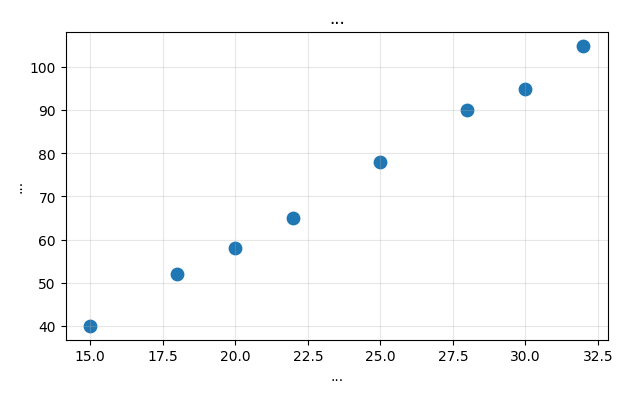

In [3]:
# TODO: scatter-график temp → sales
plt.figure(figsize=(7, 4))
plt.scatter(temp, sales, s=80)
plt.xlabel("...")
plt.ylabel("...")
plt.title("...")
plt.grid(True, alpha=0.3)
plt.show()

## Шаг 3. Подготовка $X$ и обучение модели

`sklearn` ждёт, чтобы признаки были **таблицей** (строки = объекты, столбцы = признаки).

Даже если признак один, нужен столбец:

```python
X = temp.reshape(-1, 1)
y = sales
```

Затем:
1. создайте `model = LinearRegression()`
2. обучите: `model.fit(X, y)`

**Подсказки**
- Это почти один в один, как с квартирами: `area` → `price`


In [4]:
# TODO: X, y, model, fit

# X = ...
x = temp.reshape(-1, 1)
# y = ...
y = sales
# model = ...
model = LinearRegression() 
# model.fit(...)
model.fit(x, y) 

print("Обучение завершено" )  # раскомментируйте/оставьте после fit

Обучение завершено


## Шаг 4. Прочитайте $a$ и $b$

После `fit` у модели появляются:
- `model.coef_[0]` — это **$a$** (насколько растут продажи, если температура +1 °C)
- `model.intercept_` — это **$b$** (условная «база» при температуре 0)

**Задание**
1. Сохраните `a` и `b` в переменные.
2. Напечатайте их **с пояснением словами**.
3. Ответьте в комментарии: *если на улице стало на 1 градус теплее, примерно на сколько порций вырастут продажи?*

**Подсказка**
```python
a = model.coef_[0]
b = model.intercept_
print(f"a ≈ {a:.2f}  — ...")
print(f"b ≈ {b:.2f}  — ...")
```


In [5]:
# TODO: a, b и print с пояснениями

# a = ...
a = model.coef_[0]
# b = ...
b = model.intercept_

# Комментарий: +1 °C → примерно +? порций
print(f"  +1 °C → примерно + ≈ {a:,.0f} порций")
print(f"  при 0 °C → примерно поккупают {b:,.0f} порций")

counter = 0
while a * counter + b <= 0:
    counter += 1

print(f"  при температуре {counter}°C мороженное начнут покупать")

  +1 °C → примерно + ≈ 4 порций
  при 0 °C → примерно поккупают -17 порций
  при температуре 5°C мороженное начнут покупать


## Шаг 5. Предсказание на новый день

Завтра обещают **27 °C**. Сколько порций ожидать?

**Подсказки**
- Новый объект тоже «таблицей»: `np.array([[27.0]])`
- `model.predict(...)`
- Результат — массив; удобно взять `[0]`

Напечатайте ответ понятной фразой, например:  
`При 27°C модель ожидает примерно ... порций`.


In [6]:
# TODO: предсказание для 27 градусов

# new_temp = ...
new_temp = np.array([[27.0]])  # снова «таблица» 1×1

# pred = ...
pred = model.predict(new_temp)[0]

# print(...)
print(f"Предсказанное количеств порций для 27°C: {pred:,.0f}")

Предсказанное количеств порций для 27°C: 85


## Шаг 6. Линия модели на графике

Поверх точек нарисуйте **прямую**, которую выучила модель.

**Подсказки**
1. Возьмите ровный ряд температур, например:
   ```python
   line_x = np.linspace(temp.min() - 1, temp.max() + 1, 100).reshape(-1, 1)
   line_y = model.predict(line_x)
   ```
2. `plt.scatter(...)` для данных
3. `plt.plot(line_x, line_y, color="red", ...)` для линии
4. Можно отметить точку 27°C зелёным (`plt.scatter([27], [pred], ...)`)
5. Не забудьте `legend`, подписи осей, `show()`


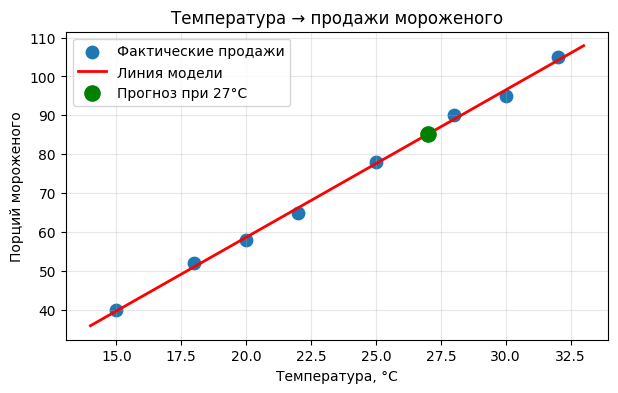

In [7]:
# TODO: точки + линия модели (+ опционально точка 27°C)
# Линия: предсказания модели на диапазоне температур
line_x = np.linspace(temp.min() - 1, temp.max() + 1, 100).reshape(-1, 1)
line_y = model.predict(line_x)

plt.figure(figsize=(7, 4))
plt.scatter(temp, sales, s=80, label="Фактические продажи")
plt.plot(line_x, line_y, color="red", linewidth=2, label="Линия модели")
plt.scatter([27], [pred], color="green", s=120, zorder=5, label="Прогноз при 27°C")
plt.xlabel("Температура, °C")
plt.ylabel("Порций мороженого")
plt.title("Температура → продажи мороженого")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Шаг 7. Насколько модель ошибается?

Посчитайте **MAE** — среднюю абсолютную ошибку (как в разделе 6 упрощённого ноутбука).

**Алгоритм**
1. `y_pred = model.predict(X)`
2. `errors = y_pred - y`  (или `sales`)
3. `abs_errors = np.abs(errors)`
4. `mae = abs_errors.mean()`

**Подсказки**
- Напечатайте таблицу: правда | предсказание | |ошибка|
- В конце: «В среднем модель ошибается примерно на … порций»

Вопрос себе: это много или мало, если продажи около 40–100?


In [8]:
# TODO: y_pred, ошибки, MAE и аккуратный print

y_pred = model.predict(x)
errors = y_pred - y
abs_errors = np.abs(errors)
mae = abs_errors.mean()

print("Предсказанные продажи:", y_pred)
print(f"Ошибки (bias) = {errors} порций")
print(f"Средняя абсолютная ошибка = {abs_errors.mean():.2f} порций")
print(f"MAE ≈ {mae:.2f} порций")

Предсказанные продажи: [ 39.74753452  51.10552268  58.67751479  66.2495069   77.60749507
  88.96548323  96.53747535 104.10946746]
Ошибки (bias) = [-0.25246548 -0.89447732  0.67751479  1.2495069  -0.39250493 -1.03451677
  1.53747535 -0.89053254] порций
Средняя абсолютная ошибка = 0.87 порций
MAE ≈ 0.87 порций


## Шаг 8. Мини-эксперимент (по желанию)

Добавьте в данные **ещё один день** или чуть измените продажи (как будто был шум) и:
1. заново сделайте `fit`;
2. посмотрите, изменились ли $a$ и $b$;
3. коротко напишите вывод в `print` или комментарии.

**Идея:** модель подстраивается под примеры — новые/шумные точки слегка двигают прямую.


In [9]:
# TODO (опционально): измените данные, переобучите, сравните a и b
temp = np.append(temp, 200.0)
sales = np.append(sales, 200.0)

x = temp.reshape(-1, 1)
y = sales

model = LinearRegression() 
model.fit(x, y) 

a = model.coef_[0]
b = model.intercept_

# Комментарий: +1 °C → примерно +? порций
print(f"  +1 °C → примерно + ≈ {a:,.0f} порций")
print(f"  при 0 °C → примерно поккупают {b:,.0f} порций")



  +1 °C → примерно + ≈ 1 порций
  при 0 °C → примерно поккупают 55 порций


## Чек-лист «я справился»

- [ ] Импорты работают
- [ ] Есть `temp` и `sales` на 8 дней
- [ ] Есть scatter-график
- [ ] Модель обучена (`fit`)
- [ ] Понятно, что такое `coef_` и `intercept_`
- [ ] Есть прогноз на 27°C
- [ ] На графике видна линия модели
- [ ] Посчитан MAE

---

## Эталон (смотрите после своей попытки)

Ниже — рабочий вариант целиком. Сверяйтесь, а не копируйте сразу.

### Ожидаемые порядки величин (примерно)

После обучения на таблице из шага 1 обычно получается что-то вроде:
- $a$ около **3.7–4.0** (порций на 1°C)
- $b$ около **−15…−20** (свободный член; на практике важен наклон $a$)
- прогноз при 27°C — порядка **85–90** порций
- MAE — небольшая (точки почти на прямой)

Точные числа могут чуть отличаться из‑за округлений — важен **порядок** и понимание шагов.


a ≈ 3.786  (порций на +1°C)
b ≈ -17.042  (свободный член)
При 27°C ожидание ≈ 85.2 порций
MAE ≈ 0.87 порций


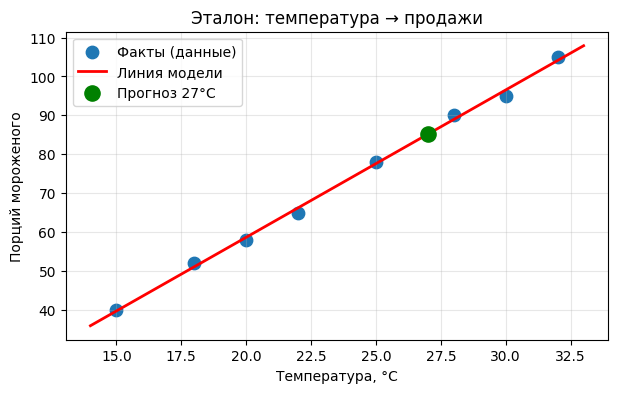

In [10]:
# ===== ЭТАЛОН (откройте/запустите после своей работы) =====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

temp = np.array([15, 18, 20, 22, 25, 28, 30, 32], dtype=float)
sales = np.array([40, 52, 58, 65, 78, 90, 95, 105], dtype=float)

X = temp.reshape(-1, 1)
y = sales

model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_
print(f"a ≈ {a:.3f}  (порций на +1°C)")
print(f"b ≈ {b:.3f}  (свободный член)")

pred_27 = model.predict(np.array([[27.0]]))[0]
print(f"При 27°C ожидание ≈ {pred_27:.1f} порций")

y_pred = model.predict(X)
mae = np.abs(y_pred - y).mean()
print(f"MAE ≈ {mae:.2f} порций")

line_x = np.linspace(temp.min() - 1, temp.max() + 1, 100).reshape(-1, 1)
line_y = model.predict(line_x)

plt.figure(figsize=(7, 4))
plt.scatter(temp, sales, s=80, label="Факты (данные)")
plt.plot(line_x, line_y, color="red", linewidth=2, label="Линия модели")
plt.scatter([27], [pred_27], color="green", s=120, zorder=5, label="Прогноз 27°C")
plt.xlabel("Температура, °C")
plt.ylabel("Порций мороженого")
plt.title("Эталон: температура → продажи")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Что дальше

1. Вернитесь к `Введение_в_ML_простыми_словами.ipynb` — разделы 5–8.
2. Попробуйте **свою** задачу по тому же шаблону, например:
   - часы учёбы → балл на тесте;
   - площадь комнаты → стоимость аренды;
   - километраж авто → цена.
3. Когда будет комфортно — откройте оригинальный учебный ноутбук.

**Главное:** вы уже умеете полный цикл  
`данные → fit → a,b → predict → график → ошибка`.
